In [1]:
!pip install requests beautifulsoup4 pandas matplotlib seaborn


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Simple Threat Intelligence Web Scraper

import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.bleepingcomputer.com/news/security/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

titles = []
links = []

for article in soup.find_all("h4"):

    link = article.find("a")

    if link:
        titles.append(link.text.strip())
        links.append(link.get("href"))

df = pd.DataFrame({
    "Threat_Title": titles,
    "URL": links
})

print(df.head())

Status Code: 403
Empty DataFrame
Columns: [Threat_Title, URL]
Index: []


In [4]:
df.to_csv("threat_intelligence_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [5]:
print("Before Cleaning:", len(df))

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print("After Cleaning:", len(df))

Before Cleaning: 0
After Cleaning: 0


In [6]:
df["Title_Length"] = df["Threat_Title"].apply(len)

print(df.describe())

       Threat_Title  URL  Title_Length
count           0.0  0.0           0.0
mean            NaN  NaN           NaN
std             NaN  NaN           NaN
min             NaN  NaN           NaN
25%             NaN  NaN           NaN
50%             NaN  NaN           NaN
75%             NaN  NaN           NaN
max             NaN  NaN           NaN


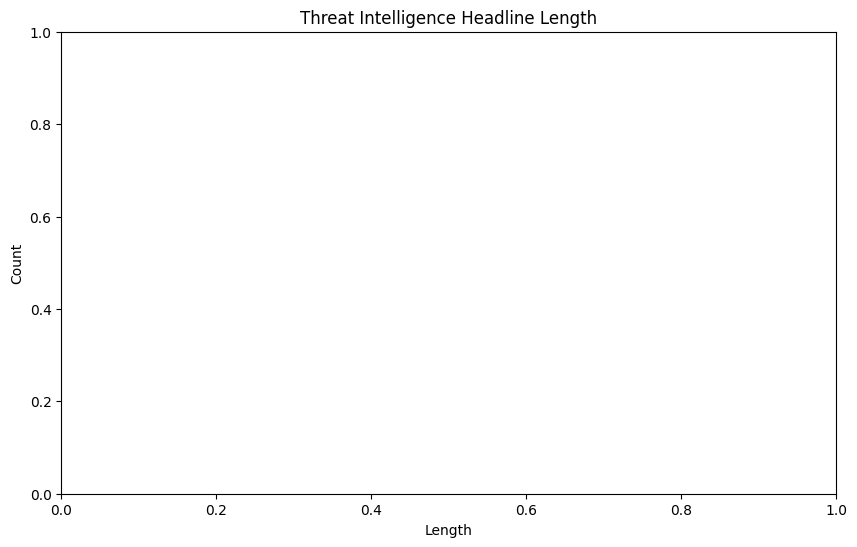

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Title_Length"],
    bins=15,
    color="red"
)

plt.title("Threat Intelligence Headline Length")
plt.xlabel("Length")
plt.ylabel("Count")

plt.show()

In [11]:
for i, title in enumerate(df["Threat_Title"][:10], start=1):
    print(i, "-", title)

In [12]:
from google.colab import files

files.download("threat_intelligence_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>